# WZA Manhattan by variation type — SNP / small indel / SV × Kendall / LFMM

kMate GrENE-Net **phase-1 replication**, matched **last_gen** pool set (355 pools), **bio1**.

Per-record GEA -> **WZA** (deg-7 SNP-number correction, Booker), run **separately per
variant class**. Here each class gets its **own panel** (rows) for **each model** (columns),
so you can read SNP / small indel / SV signal independently and compare the raw-association
(Kendall-τ) vs structure-corrected (LFMM K=16) models side by side.

- **rows** = variation type: SNP (●), small indel (▲), SV (■)
- **columns** = model: Kendall-τ (raw) | LFMM K=16 (structure-corrected)
- y = -log10(WZA block p); **red dashed = BH q<0.05 cutoff** (only multiple-testing
  correction shown). Where very few blocks pass, this cutoff can sit *above* where a
  Bonferroni line would be; where **zero** blocks pass (e.g. SV under LFMM) there is no
  cutoff to draw, so the panel is annotated "no block passes BH q<0.05".
- CAM5 block `2_1265` (Chr2 ~11.53 Mb) circled in green

> **p underflow:** a block whose SNP-number-corrected z exceeds ~38.5 gets `Z_pVal == 0`
> (float64 tail underflow, `1 − Φ(z) = 0`), not a bad block. It happens at the strongest
> block in the genome (`4_2519`, Chr4 ~12 Mb, weighted-Z ≈ 49) under Kendall small-indel.
> We **keep** it, floor the p, and **cap the panel's y-axis** just above the strongest finite
> block, drawing the underflowed point at the cap with a black outline + `(p underflow)` label
> so it doesn't take the visual range away from everything else.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WZA   = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/wza"
PLOTS = "/global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots"
TAG   = "deg7nocap"
GEN, CLIMATE = 9, "bio1"
CHROMS = [f"Chr{i}" for i in range(1, 6)]
CAM5_BLOCK = "2_1265"

# (class key, marker, colour, label, point size)
CLASSES = [
    ("snp",        "o", "#2c6fbb", "SNP",          6),
    ("smallindel", "^", "#e08214", "small indel", 14),
    ("sv",         "s", "#d62728", "SV",          26),
]
MODELS = [("kendall", "Kendall-\u03c4 (raw association)"),
          ("lfmm",    "LFMM K=16 (structure-corrected)")]

def load(model, cls):
    w = pd.read_csv(f"{WZA}/wza_{model}_{cls}_gen{GEN}_{CLIMATE}_{TAG}.csv").rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna()].copy()
    w["chrom"] = w["chrom"].astype(str)
    w = w[w["chrom"].isin(CHROMS)]
    w["underflow"] = w["Z_pVal"] <= 0
    nuf = int(w["underflow"].sum())
    if nuf:
        print(f"  {model}/{cls}: {nuf} block(s) underflowed to Z_pVal=0 (floored & flagged): "
              f"{list(w.loc[w.underflow,'block'])}")
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=1e-300))
    return w

# global genome offsets (shared x-axis across all panels); positions are model-independent
_allpos = pd.concat([load("kendall", c[0])[["chrom", "pos"]] for c in CLASSES])
CHROM_MAX = _allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
OFFSET    = CHROM_MAX.cumsum().shift(1).fillna(0)
CENTERS   = OFFSET + CHROM_MAX / 2
GENOME_END = float((OFFSET + CHROM_MAX).max())

  kendall/smallindel: 1 block(s) underflowed to Z_pVal=0 (floored & flagged): ['4_2519']


In [2]:
def bh_thresh(p):
    """Largest p passing BH q<0.05 (-> a horizontal line), or None."""
    p = np.sort(np.asarray(p, float)); m = len(p)
    k = np.where(p <= 0.05 * (np.arange(1, m + 1) / m))[0]
    return p[k.max()] if len(k) else None

def panel(ax, model, ct, show_xticks=True):
    cls, marker, color, label, size = ct
    d = load(model, cls); n = len(d)
    x = d["pos"] + d["chrom"].map(OFFSET)

    # cap just above the strongest FINITE block so an underflow point can't swamp the panel
    finite_max = d.loc[~d["underflow"], "mlogp"].max()
    cap = float(np.ceil(finite_max) + 2)

    for i, ch in enumerate(CHROMS):
        if i % 2 == 1:
            ax.axvspan(OFFSET[ch], OFFSET[ch] + CHROM_MAX[ch], color="0.95", zorder=0)

    ax.scatter(x, d["mlogp"].clip(upper=cap), s=size, marker=marker, c=color,
               alpha=0.6, edgecolors="none", rasterized=True, zorder=2)

    # underflowed blocks: pin to cap, black outline + label
    uf = d["underflow"]
    if uf.any():
        ax.scatter(x[uf], np.full(uf.sum(), cap), s=size * 3, marker=marker,
                   facecolors="none", edgecolors="black", linewidths=1.2, zorder=8)
        for xx, blk in zip(x[uf], d.loc[uf, "block"]):
            ax.annotate(f"{blk}\n(p underflow)", (xx, cap), fontsize=7, color="black",
                        ha="center", va="bottom", xytext=(0, 2), textcoords="offset points")

    # significance: BH q<0.05 only (cutoff = largest p passing the BH step-up).
    # NB: where very few blocks pass, this cutoff can sit ABOVE a Bonferroni line, and
    # where zero pass there is no cutoff to draw -- so we annotate instead of leaving a blank.
    bt = bh_thresh(d["Z_pVal"])
    nbh = int((d["Z_pVal"] <= bt).sum()) if bt is not None else 0
    # Always draw a BH q<0.05 reference line so every panel shows the bar. When >=1 block
    # passes, the line is the cutoff (largest passing p). When none pass, fall back to the
    # rank-1 BH critical value (0.05/n) -- the bar the single best block must clear -- and
    # flag it so it isn't read as an achieved cutoff.
    line_p = bt if bt is not None else 0.05 / n
    ax.axhline(-np.log10(line_p), color="red", lw=0.9, ls="--", zorder=3)
    if bt is None:
        ax.annotate("no block passes BH q<0.05\n(line = rank-1 bar 0.05/n)", xy=(0.5, 0.90),
                    xycoords="axes fraction", ha="center", fontsize=7.5, color="0.45", style="italic")

    # CAM5 highlight + per-panel readout
    c5 = d[d["block"] == CAM5_BLOCK]
    if len(c5):
        xx = c5["pos"] + c5["chrom"].map(OFFSET)
        ax.scatter(xx, c5["mlogp"].clip(upper=cap), s=130, facecolors="none",
                   edgecolors="green", linewidths=1.6, zorder=10)
        cam = f"CAM5 p={c5['Z_pVal'].iloc[0]:.1e}"
    else:
        cam = "CAM5 absent"

    ax.set_xlim(0, GENOME_END); ax.set_ylim(0, cap + max(1.0, 0.10 * cap))
    ax.set_ylabel(f"{label}\n-log10(WZA p)", fontsize=9)
    ax.set_title(f"{label} | {n:,} blocks | {nbh} BH q<0.05 | {cam}", loc="left", fontsize=9)
    if show_xticks:
        ax.set_xticks(CENTERS); ax.set_xticklabels(CHROMS); ax.set_xlabel("genome position (LD-block)")
    else:
        ax.set_xticks(CENTERS); ax.set_xticklabels([])

## Grid — variation type (rows) × model (columns)

  kendall/smallindel: 1 block(s) underflowed to Z_pVal=0 (floored & flagged): ['4_2519']


saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_byclass_grid.png


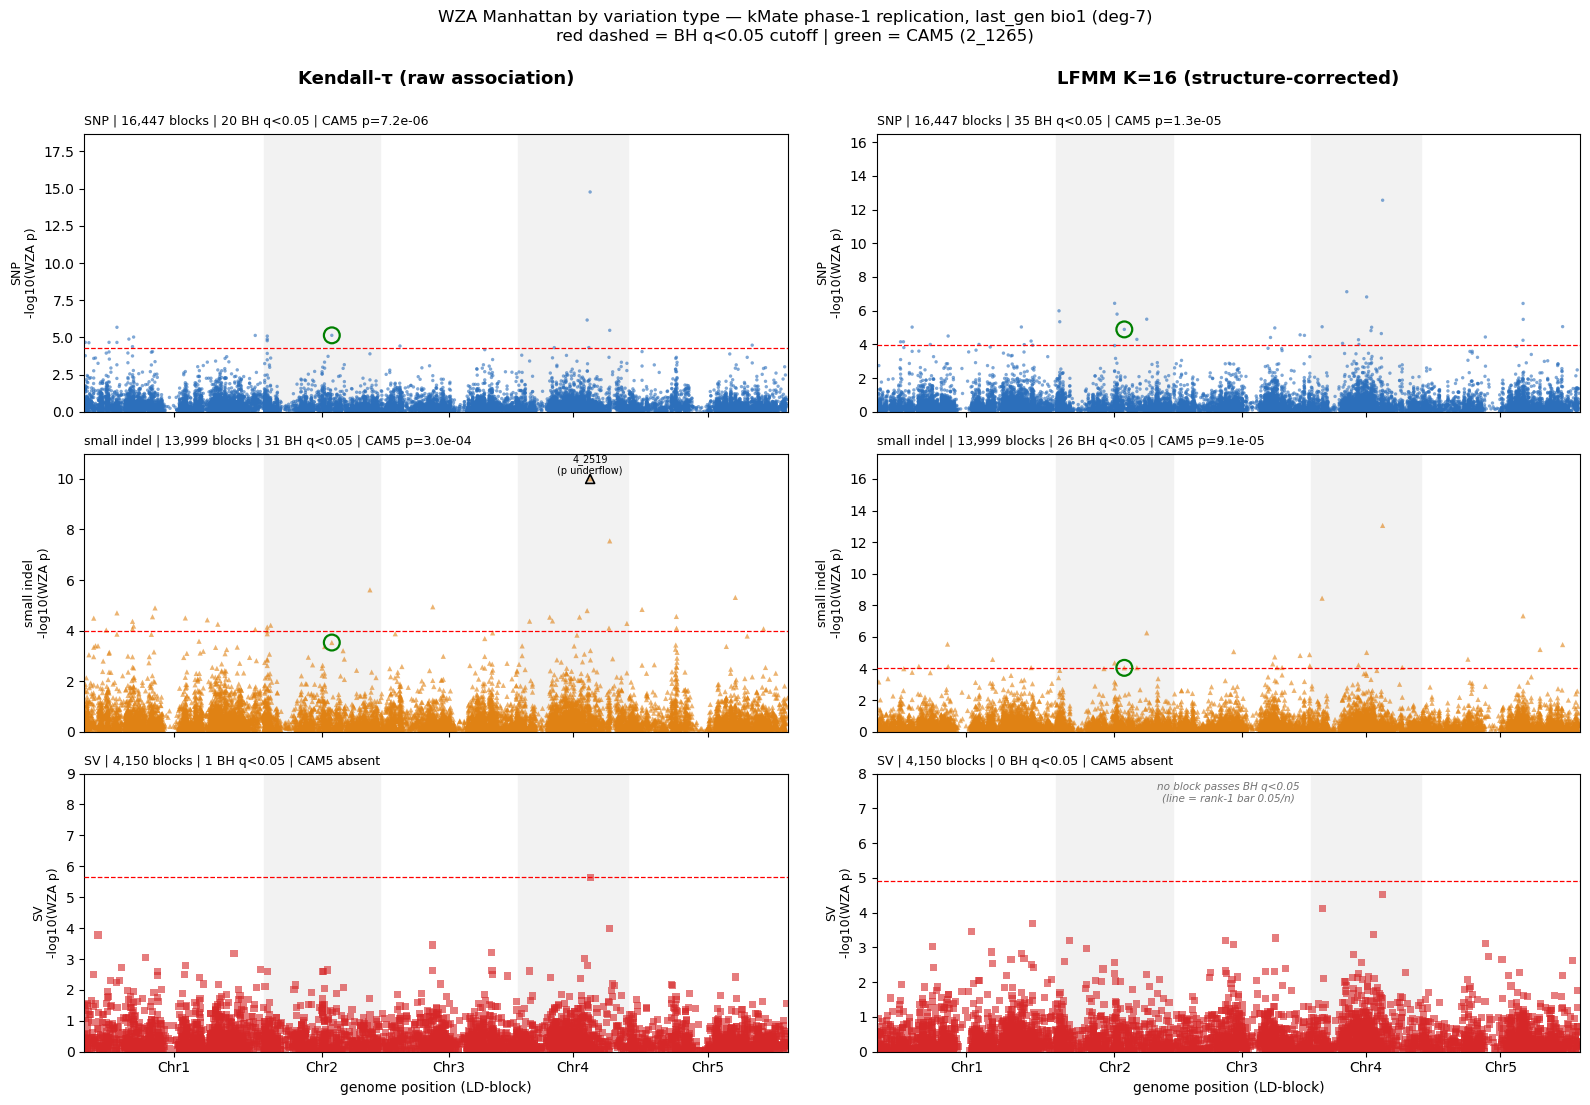

In [3]:
fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(16, 11), sharex=True)
for r, ct in enumerate(CLASSES):
    for c, (model, mtitle) in enumerate(MODELS):
        ax = axes[r, c]
        panel(ax, model, ct, show_xticks=(r == len(CLASSES) - 1))
        if r == 0:
            ax.annotate(mtitle, xy=(0.5, 1.18), xycoords="axes fraction",
                        ha="center", fontsize=13, fontweight="bold")
fig.suptitle("WZA Manhattan by variation type \u2014 kMate phase-1 replication, last_gen bio1 (deg-7)\n"
             "red dashed = BH q<0.05 cutoff | green = CAM5 (2_1265)",
             y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(f"{PLOTS}/manhattan_byclass_grid.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{PLOTS}/manhattan_byclass_grid.pdf", bbox_inches="tight")
print("saved", f"{PLOTS}/manhattan_byclass_grid.png")
plt.show()

## Per-model figures (3 class panels each)

  kendall/smallindel: 1 block(s) underflowed to Z_pVal=0 (floored & flagged): ['4_2519']


saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_byclass_kendall.png


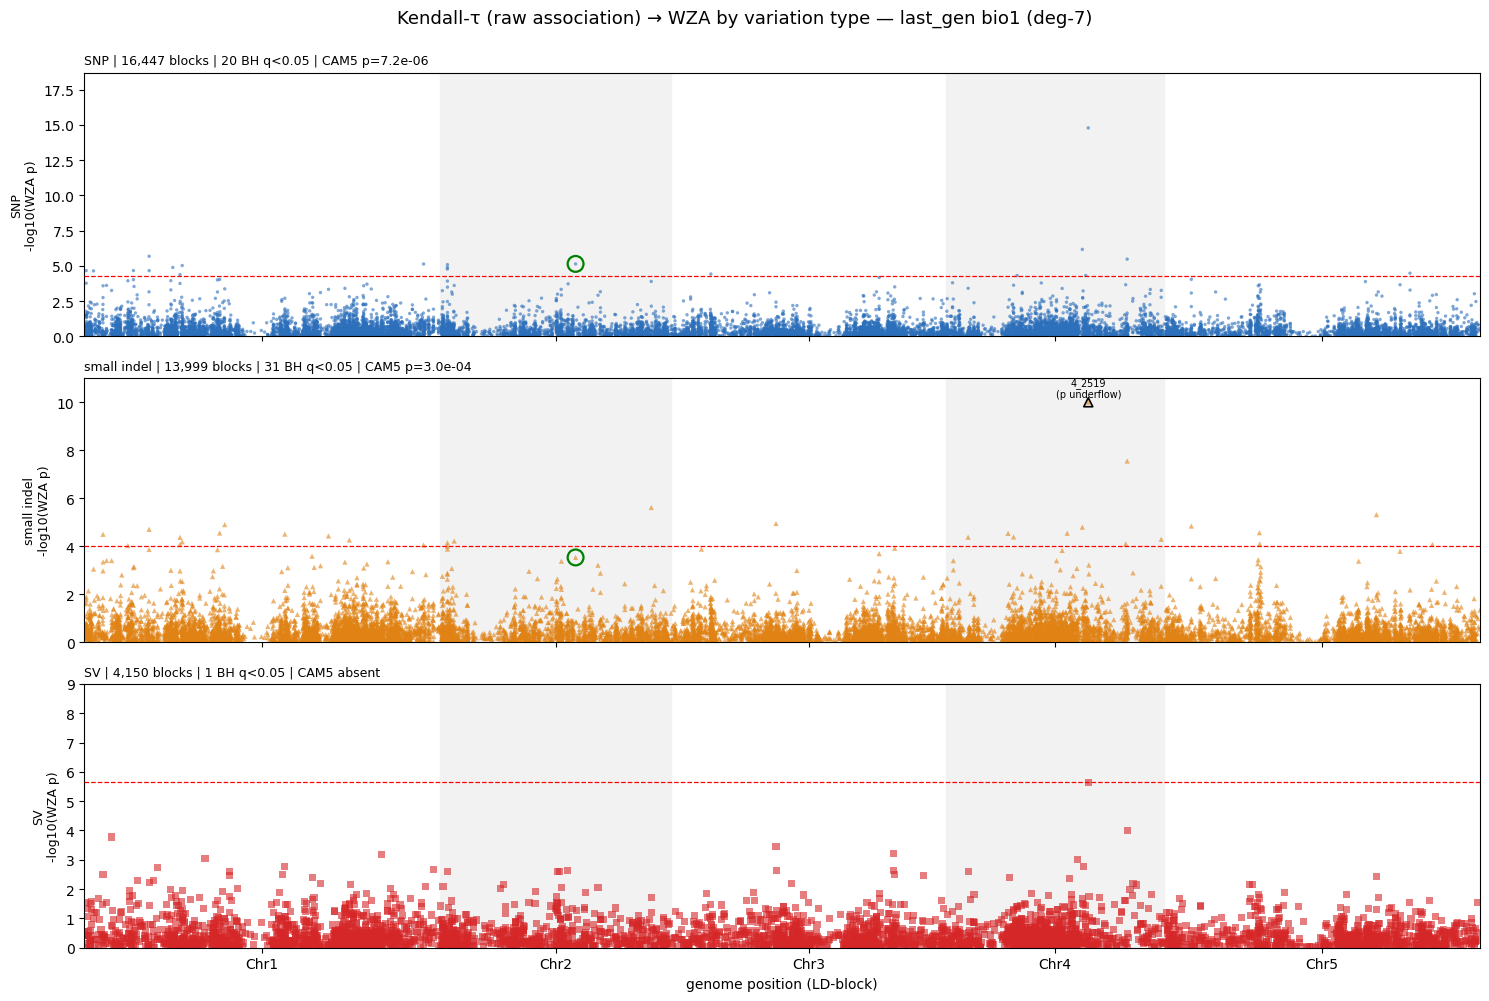

saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_byclass_lfmm.png


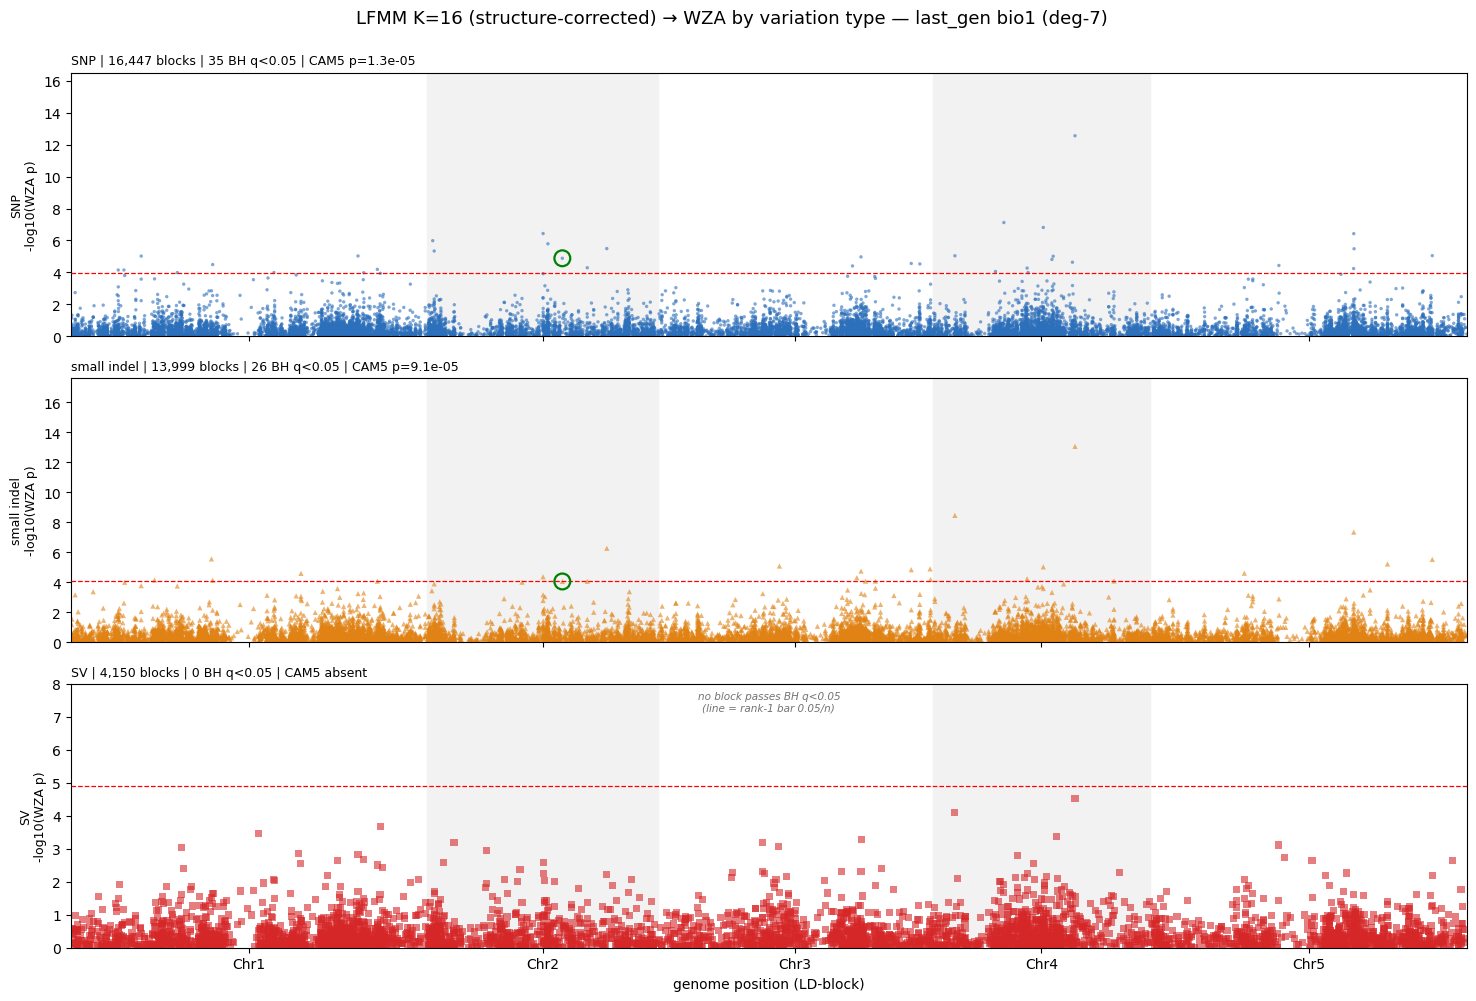

In [4]:
for model, mtitle in MODELS:
    fig, axes = plt.subplots(len(CLASSES), 1, figsize=(15, 10), sharex=True)
    for r, ct in enumerate(CLASSES):
        panel(axes[r], model, ct, show_xticks=(r == len(CLASSES) - 1))
    fig.suptitle(f"{mtitle} \u2192 WZA by variation type \u2014 last_gen bio1 (deg-7)", y=0.997, fontsize=13)
    fig.tight_layout()
    out = f"{PLOTS}/manhattan_byclass_{model}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    fig.savefig(out.replace(".png", ".pdf"), bbox_inches="tight")
    print("saved", out)
    plt.show()

## Summary table (per class × model, with CAM5)

In [5]:
def bh_q(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n)
    q[o] = (p[o] * n) / (np.arange(n) + 1); q[o] = np.minimum.accumulate(q[o][::-1])[::-1]
    return np.clip(q, 0, 1)

rows = []
for model, _ in MODELS:
    for cls, *_ in CLASSES:
        w = load(model, cls).sort_values("Z_pVal").reset_index(drop=True); n = len(w)
        p = w["Z_pVal"].to_numpy(); q = bh_q(p); r = w.index[w["block"] == CAM5_BLOCK]
        rows.append(dict(model=model, cls=cls, blocks=n, underflow=int(w["underflow"].sum()),
                         Bonf=int((p < 0.05 / n).sum()), BH_q05=int((q < 0.05).sum()),
                         CAM5_rank=(int(r[0]) + 1 if len(r) else None),
                         CAM5_p=(f"{w.loc[r[0],'Z_pVal']:.2e}" if len(r) else "absent"),
                         CAM5_q=(round(float(q[int(r[0])]), 3) if len(r) else None)))
pd.DataFrame(rows)

  kendall/smallindel: 1 block(s) underflowed to Z_pVal=0 (floored & flagged): ['4_2519']


,model,cls,blocks,underflow,Bonf,BH_q05,CAM5_rank,CAM5_p,CAM5_q
0,kendall,snp,16447,0,3,20,5.0,7.25e-06,0.019
1,kendall,smallindel,13999,1,3,31,41.0,2.96e-04,0.101
2,kendall,sv,4150,0,1,1,NaN,absent,NaN
3,lfmm,snp,16447,0,7,35,17.0,1.30e-05,0.013
4,lfmm,smallindel,13999,0,6,26,26.0,9.06e-05,0.049
5,lfmm,sv,4150,0,0,0,NaN,absent,NaN
